# 05 · Convergence as δ → 0

Notebooks 03 and 04 built the method. For a fixed polygonal flux $f_\delta$ and step data
$u^\delta_0$, front tracking computes the **exact** entropy solution $u^\delta$ of
$$
u_t + f_\delta(u)_x = 0,\qquad u(x,0) = u^\delta_0(x).
$$
Every approximation is therefore made *before* the first event: $f$ is replaced by $f_\delta$,
and $u_0$ by $u_0^\delta$. After that the computation is exact (up to floating point, §7).
This notebook asks how far $u^\delta(\cdot,t)$ is from the entropy solution $u(\cdot,t)$ (in
Kružkov's sense) of the original problem, for general data rather than a single jump. The method
goes back to Dafermos (1972).

The answer depends on how the error is measured. Besides the usual $L^1$ distance we use the
**primitive** $U(x,t)=\int_{-\infty}^x u(y,t)\,dy$, the mass of $u$ to the left of $x$ (the precise
definition, and a table of all notation, are at the start of §1):

| error | rate | status |
|---|---|---|
| $\lVert u-u^\delta\rVert_{L^1}$ | $O(\delta)$ | theorem; cannot be improved |
| $\sup_x \lvert U-U^\delta\rvert$ | $O(\delta^2)$ | theorem, **if** $u_0^\delta$ conserves mass cell by cell |

The second line is the fundamental one, and the first follows from it (§1). It also explains
the $O(\delta^2)$ shock position seen in notebook 04 (§5).

1. Three estimates · 2. Projecting the initial data · 3. Burgers against an exact solution ·
4. Nearest-node rounding · 5. Shock positions · 6. A nonconvex flux · 7. Roundoff ·
8. Try it yourself

*Main reference: S. S. Ghoshal and J. D. Towers, "A convergence rate result for front tracking
approximations of conservation laws with discontinuous flux", arXiv:2509.22952 (2025). Our
setting is their case $f=g$, a flux without spatial discontinuity. Full references at the end.*

In [1]:
# Setup: use the local checkout if present, otherwise install from GitHub.
import os, sys, subprocess, importlib, importlib.util
from pathlib import Path
REPO = "parasuramv/scalar-front-tracking"

for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
    if (candidate / "fronttrack").is_dir():
        sys.path.insert(0, str(candidate))
        break
if importlib.util.find_spec("fronttrack") is None:
    # GIT_TERMINAL_PROMPT=0: fail fast instead of waiting for a password prompt.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           f"git+https://github.com/{REPO}.git"],
                          env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    importlib.invalidate_caches()
for name in ("matplotlib", "ipywidgets"):
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", name])
if "google.colab" in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import fronttrack
from fronttrack import DiscreteFlux, FrontTracker, solve_riemann

# One small, fixed palette for the whole series.
C_FLUX, C_POLY, C_ENV, C_EXACT = "#9a9a94", "#2a78d6", "#eb6834", "#222222"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 2})
print("fronttrack", fronttrack.__version__)

fronttrack 0.2.0


## 1. Three estimates

Assume $f\in C^2$, $u_0\in BV$ with values in $[a,b]$, and $u_0$ constant outside $[-X,X]$.

**Notation.** A superscript $\delta$ always means "front tracking", a subscript $0$ always means
"at time $0$", and a capital letter always means "primitive of the lower-case function".

| symbol | meaning | in the code |
|---|---|---|
| $u(x,t)$ | exact entropy solution, flux $f$ | `burgers_exact(x, t)[0]` |
| $u^\delta(x,t)$ | front tracking solution, flux $f_\delta$ | `tr.sample(x)` |
| $u_0(x)=u(x,0)$ | exact initial data | `u0(x)` |
| $u_0^\delta(x)=u^\delta(x,0)$ | projected (step) initial data, §2 | a tracker before `run` |
| $u_L$ | far-left state, the same for all four ($0$ in our examples) | |
| $U(x,t)=\displaystyle\int_{-\infty}^x\big(u(y,t)-u_L\big)\,dy$ | primitive of $u$: mass to the left of $x$ | `burgers_exact(x, t)[1]` |
| $U^\delta(x,t)=\displaystyle\int_{-\infty}^x\big(u^\delta(y,t)-u_L\big)\,dy$ | primitive of $u^\delta$ | `primitive(tr, x)` |
| $U_0(x)=U(x,0)$, $U_0^\delta(x)=U^\delta(x,0)$ | primitives of the initial data | `U0(x)`, `primitive(tr, x)` |
| $\sup_x\lvert U-U^\delta\rvert$ | **primitive error**: the largest net mass misplaced across any point $x$ | column `prim err` in tables |
| $w_0<\dots<w_K$, $\delta$ | state nodes of $f_\delta$, and their largest spacing | `flux.u_grid` |

Subtracting $u_L$ only makes the integrals finite; it cancels in every difference $U-U^\delta$. For our
data $u_L=0$, so $U$ is literally "the mass to the left of $x$". The polygonal flux $f_\delta$
interpolates $f$ at the nodes: $f_\delta(w_k)=f(w_k)$, linear in between, with $w_0=a$, $w_K=b$,
$w_{k+1}-w_k\le\delta$. (Nodes are called $w_k$, not $u_k$, so they cannot be confused with $u_0$.)

**(E1) Interpolation.** $\;\lVert f-f_\delta\rVert_\infty\le\tfrac18\lVert f''\rVert_\infty\,\delta^2.$
The argument is cell by cell. On an open cell $(w_k,w_{k+1})$ the interpolant is linear, so
$e=f-f_\delta$ is $C^2$ there with $e''=f''$, and $e$ vanishes at both nodes. Hence
$e(u)=-\tfrac12 f''(\xi)\,(u-w_k)(w_{k+1}-u)$ for some $\xi$ in the cell, and
$(u-w_k)(w_{k+1}-u)\le\delta^2/4$. As a distribution, $f_\delta''$ has point masses at the nodes, but
the argument never differentiates across a node, so they do not enter. (Standard; Ghoshal–Towers,
Lemma 3.7.)

**(E2) Stability of primitives.**
$$
\lVert U(t)-U^\delta(t)\rVert_\infty \;\le\; \lVert U_0-U_0^\delta\rVert_\infty + t\,\lVert f-f_\delta\rVert_\infty .
$$
No convexity is needed. (Ghoshal–Towers, Lemma 3.1.) The primitive solves the Hamilton–Jacobi
equation $U_t+f(U_x)=0$, and the sup norm is the natural contraction norm for Hamilton–Jacobi.
Karlsen and Risebro (2002) prove, through front tracking, that viscosity solutions of that
equation are exactly the primitives of entropy solutions. The sup norm of $U-U^\delta$ is also
closely tied to the 1-Wasserstein distance, in which Solem (2018) proved an $O(\delta^2)$ rate for convex $f$.

**(E3) From primitives to $L^1$.** Let $w=u-u^\delta$ vanish outside $[-Y,Y]$, carry no net
mass, and let both solutions have total variation at most $K$. Then
$$
\lVert w\rVert_{L^1}\le 2\big(Y K\,\lVert W\rVert_\infty\big)^{1/2},\qquad W=U-U^\delta .
$$
*Proof.* By Cauchy–Schwarz and integration by parts ($W(\pm Y)=0$),
$\big(\int|w|\big)^2\le 2Y\!\int w^2 = 2Y\!\int w\,dW = -2Y\!\int W\,dw\le 2Y\lVert W\rVert_\infty\,\mathrm{TV}(w)$,
and $\mathrm{TV}(w)\le 2K$. $\square$ (This is Ghoshal–Towers' argument, (4.3)–(4.7).)

**Putting them together.** §2 constructs data with $\lVert U_0-U_0^\delta\rVert_\infty\le\delta^2$.
Then E1 and E2 give
$$
\lVert U(t)-U^\delta(t)\rVert_\infty\le C_1\delta^2,\qquad C_1=1+\tfrac t8\lVert f''\rVert_\infty ,
$$
and E3, with $K=\mathrm{TV}(u_0)$ and $Y=X+t\,\mathrm{Lip}(f)$, gives
$$
\lVert u(t)-u^\delta(t)\rVert_{L^1}\le 2\big(Y\,\mathrm{TV}(u_0)\,C_1\big)^{1/2}\,\delta .
$$
This is Ghoshal–Towers, Theorem 4.3, with a smaller $Y$. Their $Y=X+2t\,\mathrm{Lip}(f)$ comes from
the time-step restriction of the Godunov scheme used in their proof. Finite speed of propagation
gives $X+t\,\mathrm{Lip}(f)$ directly, for $u$ and for $u^\delta$ alike, since the slopes of $f_\delta$ are
bounded by $\mathrm{Lip}(f)$. First-order convergence in $L^1$ is classical (Lucier, 1986).
Their route is different and makes the $\delta^2$ primitive estimate the source of it.

$O(\delta)$ in $L^1$ cannot be improved: $u^\delta$ only takes grid values, so even where $u$ is smooth
the error is about $\delta/4$ per unit length. Monotone finite-volume schemes are worse still. Their
general $L^1$ rate is $\delta^{1/2}$ (Kuznetsov, 1976), and this is sharp (Şabac, 1997). Front tracking
does better because it adds no numerical viscosity: $u^\delta$ is an exact entropy solution of a
nearby problem.

The rest of the notebook measures both rates and checks that the observed errors stay below
the bounds.

## 2. Projecting the initial data

Front tracking needs step data $u_0^\delta$ whose values are grid nodes. How we build it from $u_0$
decides the initial primitive error. Recall the two primitives at $t=0$:
$$
U_0(x)=\int_{-\infty}^x\big(u_0(y)-u_L\big)\,dy,\qquad U_0^\delta(x)=\int_{-\infty}^x\big(u_0^\delta(y)-u_L\big)\,dy .
$$
Their difference $U_0^\delta(x)-U_0(x)$ is the net mass that the projection has moved from the right
of $x$ to its left. E2 says this initial error is carried forward in time without growing. So we want
it small **at every $x$**, not just on average.

The library's `FrontTracker.from_values` samples $u_0$ and rounds each value to the nearest
node. That is cheap, but it does not conserve mass locally. Each cell makes an error of up to
$\delta/2$ in $u$, and on a stretch where these errors share a sign they add up in
$U_0^\delta-U_0$. Rounding can even increase the total variation.

Ghoshal and Towers (their (3.35)–(3.38)) use a different projection:

* partition $[-X,X]$ into cells of width $\le\delta$ such that $\mathrm{TV}(u_0)\le\delta$ on each
  open cell (so every jump larger than $\delta$ sits on a cell edge);
* take the **exact cell average** on each cell.

Then $U_0^\delta=U_0$ at every cell edge, because each cell carries exactly its own mass. Inside a
cell $|U_0^\delta-U_0|\le(\text{width})\cdot\mathrm{TV}\le\delta^2$ (their Lemma 3.7). Averaging also
gives $\mathrm{TV}(u_0^\delta)\le\mathrm{TV}(u_0)$.

The averages are not grid nodes. `fronttrack` needs node values, so we **add the averages to the
state grid**. The grid stays sorted with spacing $\le\delta$, and $f_\delta$ still interpolates $f$,
so E1 is unchanged. `DiscreteFlux` already accepts nonuniform grids.

Our test data for Burgers' flux $f(u)=u^2/2$ are a bump next to a block:
$$
u_0(x)=A\,(1-x^2)_+ + B\,\mathbf 1_{(1,\,1.5)}(x),\qquad A=0.68,\;B=0.6 .
$$
The block gives a jump up (a rarefaction) and a jump down (a shock) at $t=0$. $A$ is chosen so that
the top of the bump is not a grid value for any $\delta$ used below.

For Burgers the entropy solution is known exactly through the Hopf–Lax formula
$U(x,t)=\min_y\big[U_0(y)+\tfrac{(x-y)^2}{2t}\big]$, with $u=(x-y^*)/t$. The code minimises over a
finite candidate set that provably contains the minimiser, so the reference involves no grid search
and no tolerance. Primitives of step functions are computed exactly (they are piecewise linear).

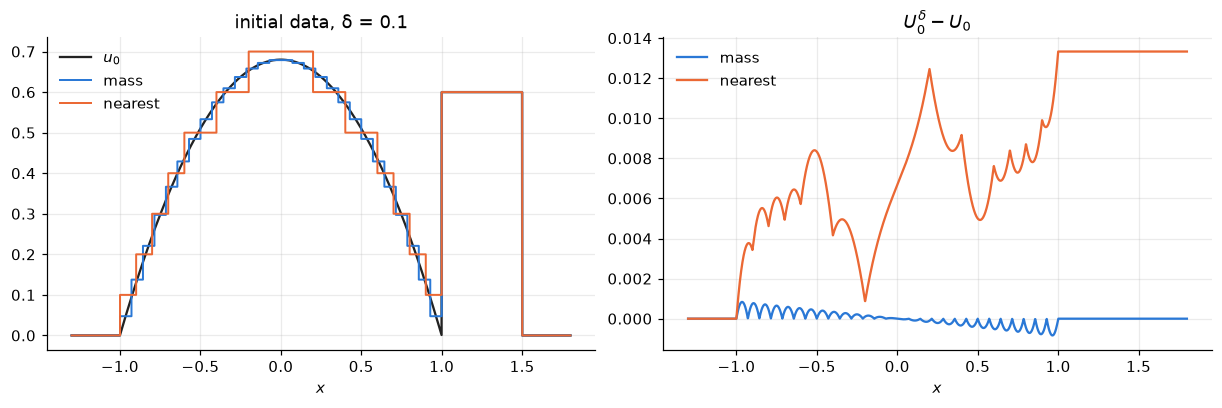

In [3]:
burgers = lambda u: 0.5 * u**2
A, B = 0.68, 0.6            # bump height (not a grid value), block height (a grid value)

def u0(x, A=A, B=B):
    """A(1-x^2) on [-1,1], plus a block of height B on (1, 1.5); zero elsewhere."""
    x = np.asarray(x, dtype=float)
    return A * np.clip(1 - x**2, 0, None) + B * ((x > 1) & (x < 1.5))

def U0(x, A=A, B=B):
    """Primitive of u0 from -infinity (u0 = 0 far left)."""
    y = np.clip(x, -1, 1)
    return A * (y - y**3 / 3 + 2 / 3) + B * np.clip(np.asarray(x) - 1, 0, 0.5)

def burgers_exact(x, t, A=A, B=B):
    """Exact entropy solution for Burgers and the data above, via Hopf–Lax:
    U(x,t) = min_y [U0(y) + (x-y)^2/(2t)],  u(x,t) = (x - y*)/t.
    Every y gives an upper bound, so it is enough to minimise over a candidate set
    that surely contains the minimiser: the stationary points y + t u0(y) = x of each
    smooth piece of u0, and the jump points of u0. No grid search, no tolerance."""
    x = np.asarray(x, dtype=float)
    cands = [x, x - B * t, np.full_like(x, -1.0), np.full_like(x, 1.0), np.full_like(x, 1.5)]
    disc = 1 - 4 * t * A * (x - t * A)               # t A y^2 - y + (x - t A) = 0
    root = np.sqrt(np.clip(disc, 0, None))
    for sign in (1, -1):
        y = np.clip((1 + sign * root) / (2 * t * A), -1, 1)
        cands.append(np.where(disc >= 0, y, x))
    Y = np.array(cands)
    vals = U0(Y, A, B) + (x - Y)**2 / (2 * t)
    k = np.argmin(vals, axis=0)
    y_star = Y[k, np.arange(x.size)]
    return (x - y_star) / t, vals[k, np.arange(x.size)], y_star

def mass_projection(f, U0, breaks, delta, lip, grid_lo, grid_hi, u_out=0.0):
    """Ghoshal–Towers projection. Cells of width <= delta and TV(u0) <= delta on each
    open cell (width delta/lip where |u0'| <= lip; jumps only at `breaks`, which become
    cell edges). States are exact cell averages, added to the state grid."""
    h = delta / max(1.0, lip)
    edges = [breaks[0]]
    for a, b in zip(breaks[:-1], breaks[1:]):
        edges.extend(np.linspace(a, b, int(np.ceil((b - a) / h)) + 1)[1:])
    edges = np.array(edges)
    avg = np.diff(U0(edges)) / np.diff(edges)
    nodes = np.linspace(grid_lo, grid_hi, int(round((grid_hi - grid_lo) / delta)) + 1)
    grid = np.unique(np.concatenate([nodes, avg]))
    grid = grid[np.concatenate([[True], np.diff(grid) > 1e-12])]   # merge roundoff twins
    flux = DiscreteFlux(f, grid)
    states = flux.state_index(np.concatenate([[u_out], avg, [u_out]]))
    return FrontTracker(flux, edges, states, record_history=False)

def nearest_projection(f, u0, lo, hi, delta, grid_lo, grid_hi, u_out=0.0):
    """The library's default: sample u0 at cell midpoints (width delta), round to nodes."""
    edges = np.linspace(lo, hi, int(round((hi - lo) / delta)) + 1)
    nodes = np.linspace(grid_lo, grid_hi, int(round((grid_hi - grid_lo) / delta)) + 1)
    values = np.concatenate([[u_out], u0(0.5 * (edges[1:] + edges[:-1])), [u_out]])
    return FrontTracker.from_values(DiscreteFlux(f, nodes), edges, values,
                                    record_history=False)

def primitive(tr, x):
    """Exact primitive of the step solution, int_{-inf}^x (u - u_left): piecewise linear."""
    g = tr.flux.u_grid
    p = np.array([fr.x for fr in tr.fronts])
    v = g[[tr.left_state] + [fr.iR for fr in tr.fronts]] - g[tr.left_state]
    if p.size == 0:
        return np.zeros_like(np.asarray(x, dtype=float))
    cum = np.concatenate([[0.0], np.cumsum(np.diff(p) * v[1:-1])])
    k = np.searchsorted(p, x, side="right")
    j = np.maximum(k - 1, 0)
    return np.where(k == 0, 0.0, cum[j] + (x - p[j]) * v[k])

def front_positions(tr):
    return np.array([fr.x for fr in tr.fronts])

def exact_shocks(t, A=A, B=B, lo=-1.5, hi=8.0, n=200001):
    """Exact shock locations: y*(x) is nondecreasing and jumps across a shock.
    Bracket each jump on a grid, then bisect to machine precision."""
    x = np.linspace(lo, hi, n)
    _, _, y = burgers_exact(x, t, A, B)
    out = []
    for i in np.nonzero(np.diff(y) > 1e-6 + 10 * (x[1] - x[0]))[0]:
        a, b = x[i], x[i + 1]
        ya, yb = y[i], y[i + 1]
        for _ in range(100):
            m = 0.5 * (a + b)
            if m in (a, b):
                break
            ym = burgers_exact(np.array([m]), t, A, B)[2][0]
            if ym - ya < yb - ym:
                a, ya = m, ym
            else:
                b, yb = m, ym
        out.append(0.5 * (a + b))
    return np.array(out)

d = 0.1
x = np.linspace(-1.3, 1.8, 3001)
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
a.plot(x, u0(x), color=C_EXACT, lw=1.5, label="$u_0$")
for proj, c in (("mass", C_POLY), ("nearest", C_ENV)):
    tr = (mass_projection(burgers, U0, [-1.0, 1.0, 1.5], d, 2 * A, 0.0, 1.0) if proj == "mass"
          else nearest_projection(burgers, u0, -1.0, 1.5, d, 0.0, 1.0))
    a.step(x, tr.sample(x), where="post", color=c, lw=1.3, label=proj)
    b.plot(x, primitive(tr, x) - U0(x), color=c, lw=1.5, label=proj)
a.set(xlabel="$x$", title=f"initial data, δ = {d}")
b.set(xlabel="$x$", title=r"$U_0^\delta - U_0$")
a.legend(frameon=False); b.legend(frameon=False)
plt.show()

Left: the two step approximations $u_0^\delta$. Right: the mass each one misplaces, $U_0^\delta(x)-U_0(x)$.
With nearest-node rounding the misplaced mass drifts with one sign across the bump and the block.
With cell averages it returns to zero at every cell edge.

## 3. Burgers against an exact solution

We run both rates at $T=3$, after the bump has formed its shock, for $\delta=0.1\cdot2^{-k}$. The
bounds of §1 use $\lVert f''\rVert_\infty=1$, $\mathrm{Lip}(f)=1$ on $[0,1]$, $X=1.5$ (so $Y=4.5$) and
$\mathrm{TV}(u_0)=2A+2B$.

    delta         L1  rate  L1/bound   prim err  rate /delta^2  /bound
 0.100000  3.927e-02           0.049  2.184e-03         0.2184   0.159
 0.050000  2.056e-02  0.93     0.052  6.139e-04  1.83   0.2456   0.179
 0.025000  1.039e-02  0.98     0.052  1.774e-04  1.79   0.2838   0.206
 0.012500  5.192e-03  1.00     0.052  4.816e-05  1.88   0.3082   0.224
 0.006250  2.617e-03  0.99     0.053  1.278e-05  1.91   0.3272   0.238
 0.003125  1.312e-03  1.00     0.053  3.313e-06  1.95   0.3392   0.247


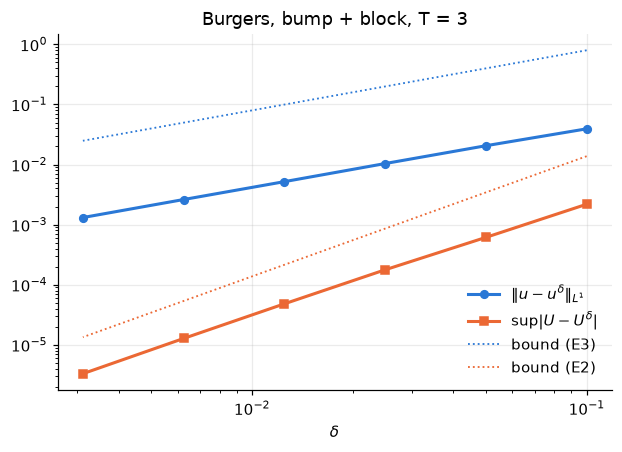

In [4]:
T = 3.0
deltas = 0.1 / 2 ** np.arange(6)
x_dense = np.linspace(-1.5, 6.0, 400_001)
shocks = exact_shocks(T)

def errors(tr, T, A=A, B=B, shocks=shocks):
    """L1 error (dense quadrature) and exact sup of |U - U_delta| over dense points,
    every front and every exact shock."""
    xs = np.sort(np.concatenate([x_dense, front_positions(tr), shocks]))
    u_ex, U_ex, _ = burgers_exact(xs, T, A, B)
    L1 = np.trapezoid(np.abs(tr.sample(xs) - u_ex), xs)
    return L1, np.max(np.abs(primitive(tr, xs) - U_ex))

C1, Y, TV0 = 1 + T / 8, 1.5 + T, 2 * A + 2 * B
res = {"mass": [], "nearest": []}
for d in deltas:
    res["mass"].append(errors(mass_projection(burgers, U0, [-1.0, 1.0, 1.5], d, 2 * A,
                                              0.0, 1.0).run(T), T))
    res["nearest"].append(errors(nearest_projection(burgers, u0, -1.0, 1.5, d,
                                                    0.0, 1.0).run(T), T))
res = {k: np.array(v) for k, v in res.items()}
L1, P = res["mass"].T

# Outputs are collected and printed once per cell, so that the saved notebook does not
# depend on when the kernel happened to flush stdout.
lines = [f"{'delta':>9} {'L1':>10} {'rate':>5} {'L1/bound':>9} {'prim err':>10} {'rate':>5}"
         f" {'/delta^2':>8} {'/bound':>7}"]
for i, d in enumerate(deltas):
    r1 = "" if i == 0 else f"{np.log2(L1[i-1] / L1[i]):5.2f}"
    r2 = "" if i == 0 else f"{np.log2(P[i-1] / P[i]):5.2f}"
    lines.append(f"{d:9.6f} {L1[i]:10.3e} {r1:>5} {L1[i] / (2 * np.sqrt(Y * TV0 * C1) * d):9.3f}"
                 f" {P[i]:10.3e} {r2:>5} {P[i] / d**2:8.4f} {P[i] / (C1 * d**2):7.3f}")
print("\n".join(lines))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(deltas, L1, "o-", color=C_POLY, ms=5, label=r"$\|u-u^\delta\|_{L^1}$")
ax.loglog(deltas, P, "s-", color=C_ENV, ms=5, label=r"$\sup|U-U^\delta|$")
ax.loglog(deltas, 2 * np.sqrt(Y * TV0 * C1) * deltas, ":", color=C_POLY, lw=1.2,
          label="bound (E3)")
ax.loglog(deltas, C1 * deltas**2, ":", color=C_ENV, lw=1.2, label="bound (E2)")
ax.set(xlabel=r"$\delta$", title=f"Burgers, bump + block, T = {T:g}")
ax.legend(frameon=False)
plt.show()

Both rates are as predicted: $1$ in $L^1$ and $2$ for the primitive. Both ratios to the bounds
stay below $1$. The primitive bound is within a factor of four. The $L^1$ bound is loose by a factor
of about 20, and most of that comes from E3 itself: with the *observed* primitive error in place of its
bound, E3 still overestimates by about 10. Cauchy–Schwarz spreads the error evenly over the whole
support, and $\mathrm{TV}(w)\le2K$ ignores cancellation.

### How the primitive error grows in time

For this flux ($\lVert f''\rVert_\infty=1$) and this projection, E1 and E2 bound the primitive error at time
$t$ by the sum of two terms:
$$
\sup_x|U-U^\delta|(t)\;\le\;\underbrace{\sup_x|U_0-U_0^\delta|}_{\text{error in the data, }\le\,\delta^2}
\;+\;\underbrace{t\,\lVert f-f_\delta\rVert_\infty}_{\text{error from the flux, }\le\,\frac t8\delta^2}.
$$
The first term is present at $t=0$ and E2 says it never grows. The second starts at zero and grows
linearly: at every instant the polygonal flux moves mass at a rate that differs from the true rate by
at most $\lVert f-f_\delta\rVert_\infty$.

Both terms carry a factor $\delta^2$, so we divide by it. The quantity plotted below is
$$
R(t)=\frac{\sup_x|U(x,t)-U^\delta(x,t)|}{\delta^2},\qquad\text{and E1, E2 say}\quad R(t)\le 1+\frac t8 .
$$
If the theory has the right order in $\delta$, $R(t)$ should hardly change when $\delta$ is divided by four.
The cell computes $R$ at nine times for $\delta=0.0125$ and $\delta=0.003125$.

delta=0.0125: t=0: 0.091  t=0.25: 0.091  t=0.5: 0.091  t=1: 0.103  t=1.5: 0.154  t=2: 0.205  t=3: 0.308  t=4: 0.411  t=6: 0.616
delta=0.003125: t=0: 0.092  t=0.25: 0.092  t=0.5: 0.092  t=1: 0.113  t=1.5: 0.170  t=2: 0.226  t=3: 0.339  t=4: 0.452  t=6: 0.678


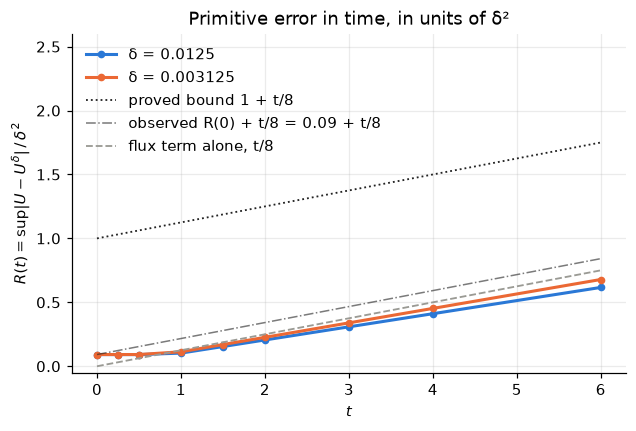

In [5]:
times = np.array([0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])
x_wide = np.linspace(-1.5, 8.0, 400_001)
fig, ax = plt.subplots(figsize=(6.5, 4))
lines = []
for d, c in ((0.0125, C_POLY), (0.003125, C_ENV)):
    tr = mass_projection(burgers, U0, [-1.0, 1.0, 1.5], d, 2 * A, 0.0, 1.0)
    ratio = []
    for t in times:
        tr.run(t)
        xs = np.sort(np.concatenate([x_wide, front_positions(tr)]))
        if t == 0:
            U_ex = U0(xs)
        else:
            xs = np.sort(np.concatenate([xs, exact_shocks(t)]))
            U_ex = burgers_exact(xs, t)[1]
        ratio.append(np.max(np.abs(primitive(tr, xs) - U_ex)) / d**2)
    ax.plot(times, ratio, "o-", color=c, ms=4, label=f"δ = {d}")
    lines.append(f"delta={d}: " + "  ".join(f"t={t:g}: {r:.3f}" for t, r in zip(times, ratio)))
print("\n".join(lines))
R0 = ratio[0]                                   # observed data error, finer delta
ax.plot(times, 1 + times / 8, ":", color=C_EXACT, lw=1.2, label="proved bound 1 + t/8")
ax.plot(times, R0 + times / 8, "-.", color=C_EXACT, lw=1, alpha=0.6,
        label=f"observed R(0) + t/8 = {R0:.2f} + t/8")
ax.plot(times, times / 8, "--", color=C_FLUX, lw=1.2, label="flux term alone, t/8")
ax.set(xlabel="$t$", ylabel=r"$R(t)=\sup|U-U^\delta|\,/\,\delta^2$",
       title="Primitive error in time, in units of δ²", ylim=(-0.05, 2.6))
ax.legend(frameon=False, loc="upper left")
plt.show()

How to read the plot, from left to right:

1. **At $t=0$**, $R(0)\approx0.09$ for both $\delta$. This is the data error alone: the projection
   misplaces about $0.09\,\delta^2$ of mass at worst, well below the $\delta^2$ that Lemma 3.7 allows.
2. **Up to $t\approx0.5$**, $R(t)$ stays at that value. The flux term $t/8$ (grey dashed line) is still
   smaller than the data error, and the data error is carried along without growing, as E2 says.
3. **From $t\approx1$ on**, $R(t)$ grows linearly and runs just below the dashed line $t/8$. Now the
   flux term is the larger one, and it is what we see.
4. **The two terms do not add up.** If they did, the curves would follow the dash-dotted line
   $R(0)+t/8$. From $t\approx1$ on they stay below even $t/8$. So in this example the error behaves like the **larger** of
   the two terms, not their sum. The proved bound (dotted) is the sum, which is why it is loose by
   about the data term.
5. **The constant $\tfrac18$ is nearly sharp.** When $\delta$ is divided by four, the late-time values move
   up towards $t/8$ (at $t=6$: $0.62$, then $0.68$, against $0.75$). So the factor $\tfrac18\lVert f''\rVert_\infty$ in
   E1 and E2 cannot be improved much for these data.

Points 4 and 5 are observations for one data set, not theorems. We have not worked out which part of
the solution attains the flux term.

## 4. Nearest-node rounding

Now the same experiment with the library's default projection. The first figure of §2 predicts
the problem: its initial primitive error is already of order $\delta$ in places.

    delta    L1 mass  L1 nearest   sup mass  sup nearest  nearest/delta^2
 0.100000  3.927e-02   1.005e-01  2.184e-03    1.333e-02             1.33
 0.050000  2.056e-02   4.306e-02  6.139e-04    5.482e-03             2.19
 0.025000  1.039e-02   2.238e-02  1.774e-04    1.901e-03             3.04
 0.012500  5.192e-03   1.181e-02  4.816e-05    2.038e-03            13.04
 0.006250  2.617e-03   5.367e-03  1.278e-05    1.302e-04             3.33
 0.003125  1.312e-03   2.702e-03  3.313e-06    9.115e-05             9.33


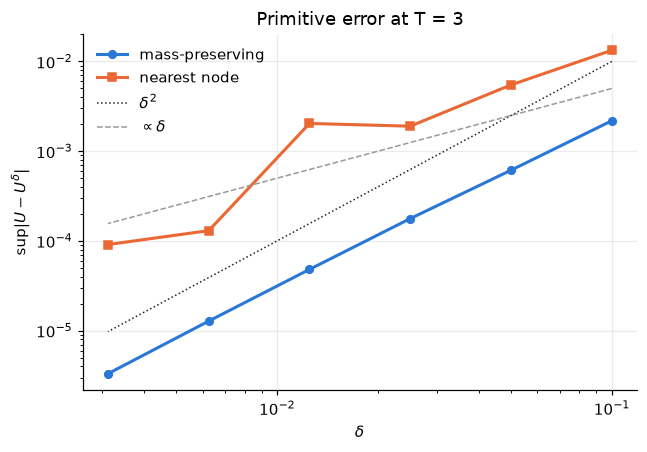

In [6]:
Ln, Pn = res["nearest"].T
lines = [f"{'delta':>9} {'L1 mass':>10} {'L1 nearest':>11} {'sup mass':>10} {'sup nearest':>12}"
         f" {'nearest/delta^2':>16}"]
for i, d in enumerate(deltas):
    lines.append(f"{d:9.6f} {L1[i]:10.3e} {Ln[i]:11.3e} {P[i]:10.3e} {Pn[i]:12.3e}"
                 f" {Pn[i] / d**2:16.2f}")
print("\n".join(lines))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(deltas, P, "o-", color=C_POLY, ms=5, label="mass-preserving")
ax.loglog(deltas, Pn, "s-", color=C_ENV, ms=5, label="nearest node")
ax.loglog(deltas, deltas**2, ":", color=C_EXACT, lw=1, label=r"$\delta^2$")
ax.loglog(deltas, 0.05 * deltas, "--", color=C_FLUX, lw=1, label=r"$\propto\delta$")
ax.set(xlabel=r"$\delta$", ylabel=r"$\sup|U-U^\delta|$", title=f"Primitive error at T = {T:g}")
ax.legend(frameon=False)
plt.show()

In $L^1$ both projections are first order, and nearest-node rounding costs only a factor of about
two. The primitive is a different story. With nearest-node rounding its error is erratic, is 6 to
40 times the mass-preserving one, and has no clean rate. It depends on
where the grid values happen to fall relative to the data.

A heuristic for the size of the error: rounding errors have one sign wherever $u_0$ stays within a
single grid cell. Near a smooth maximum at a non-grid value that stretch has length about
$\sqrt{\delta/|u_0''|}$, giving an error of about $\delta^{3/2}$. On a plateau at a non-grid value the
stretch has fixed length, giving an error of order $\delta$. Neither is $\delta^2$.

The practical lesson for anyone using `fronttrack`: if you care about *where* things are (shock
positions, mass distribution), project the data with cell averages, not by rounding.

## 5. Shock positions

Suppose $u$ has an isolated shock of strength $[u]$ at $x_s$, and $u^\delta$ has it at $x_s+e$. Just
beside the shock, $U^\delta-U\approx\pm[u]\,e$. This suggests
$$
|e|\;\lesssim\;\frac{\sup|U-U^\delta|}{[u]} = O(\delta^2).
$$
This is a heuristic corollary of E2, not a proved statement: it ignores the $O(\delta)$ differences in
the states next to the shock. In notebook 04 the data were node-valued, so $U_0^\delta=U_0$ exactly and
only the flux term $\tfrac t8\delta^2$ was present. That is why the shock position there came out at
$O(\delta^2)$.

Test: the bump alone ($B=0$), which forms a single shock. The approximate shock is the front with
the largest jump.

exact shock at x = 1.678438861419, strength [u] = 0.640161
    delta   |e| mass  |e|/d^2  |e| nearest  heuristic C1 d^2/[u]
 0.100000   2.99e-04    0.030     2.16e-02  2.15e-02
 0.050000   3.14e-06    0.001     4.07e-04  5.37e-03
 0.025000   1.53e-05    0.024     1.52e-03  1.34e-03
 0.012500   4.83e-06    0.031     2.09e-03  3.36e-04
 0.006250   5.93e-07    0.015     1.72e-04  8.39e-05
 0.003125   1.15e-07    0.012     7.49e-05  2.10e-05
 0.001563   2.44e-08    0.010     8.98e-06  5.24e-06


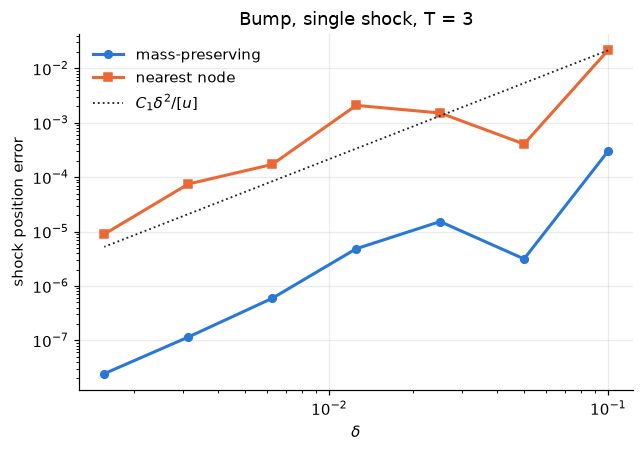

In [7]:
T5 = 3.0
xs_exact = exact_shocks(T5, A, 0.0)[0]
u_left = burgers_exact(np.array([xs_exact - 1e-9]), T5, A, 0.0)[0][0]
lines = [f"exact shock at x = {xs_exact:.12f}, strength [u] = {u_left:.6f}"]
bump_U0 = lambda z: U0(z, A, 0.0)
bump_u0 = lambda z: u0(z, A, 0.0)

def shock_front(tr):
    g = tr.flux.u_grid
    return max(tr.fronts, key=lambda f: abs(g[f.iR] - g[f.iL])).x

deltas5 = 0.1 / 2 ** np.arange(7)
pos = {"mass": [], "nearest": []}
for d in deltas5:
    pos["mass"].append(shock_front(mass_projection(burgers, bump_U0, [-1.0, 1.0], d, 2 * A,
                                                   0.0, 1.0).run(T5)))
    pos["nearest"].append(shock_front(nearest_projection(burgers, bump_u0, -1.0, 1.0, d,
                                                         0.0, 1.0).run(T5)))
err = {k: np.abs(np.array(v) - xs_exact) for k, v in pos.items()}
bound = (1 + T5 / 8) * deltas5**2 / u_left
lines.append(f"{'delta':>9} {'|e| mass':>10} {'|e|/d^2':>8} {'|e| nearest':>12}"
             "  heuristic C1 d^2/[u]")
for i, d in enumerate(deltas5):
    lines.append(f"{d:9.6f} {err['mass'][i]:10.2e} {err['mass'][i] / d**2:8.3f}"
                 f" {err['nearest'][i]:12.2e}  {bound[i]:.2e}")
print("\n".join(lines))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(deltas5, err["mass"], "o-", color=C_POLY, ms=5, label="mass-preserving")
ax.loglog(deltas5, err["nearest"], "s-", color=C_ENV, ms=5, label="nearest node")
ax.loglog(deltas5, bound, ":", color=C_EXACT, lw=1.2, label=r"$C_1\delta^2/[u]$")
ax.set(xlabel=r"$\delta$", ylabel="shock position error", title="Bump, single shock, T = 3")
ax.legend(frameon=False)
plt.show()

With cell averages the shock position error stays below $C_1\delta^2/[u]$, by a factor of 30 or
more, and falls at roughly second order. It is not monotone, because the front with the largest jump changes as the staircase
next to the shock is absorbed one step at a time. With nearest-node rounding the error is again
irregular and much larger.

## 6. A nonconvex flux

E2 does not use convexity, so the $\delta^2$ primitive estimate holds for $f(u)=u^3$ too. There is no
Hopf–Lax formula here, so the reference is front tracking itself at $\delta_{\rm ref}=0.0125/8$, with the
same projection. This is a **self-convergence** test. The reference has its own error, about
$1/64$ of the finest error below in the primitive and $1/8$ in $L^1$. Between two step functions both
errors are computed exactly: $L^1$ over the merged breakpoints, and the primitive difference at the
fronts, where its maximum is attained (both primitives are piecewise linear).

Data: $u_0(x)=0.8\sin(\pi x)$ on $[-1,1]$, zero outside, at $T=1$. The states cross the inflection
point $u=0$, so the Riemann problems produce compound waves. Here $\lVert f''\rVert_\infty=4.8$ on
$[-0.8,0.8]$.

In [8]:
import math
cubic = lambda u: u**3
sine_U0 = lambda z: 0.8 / np.pi * (-np.cos(np.pi * np.clip(z, -1, 1)) - 1)
T6, lip6 = 1.0, 0.8 * np.pi
run6 = lambda d: mass_projection(cubic, sine_U0, [-1.0, 1.0], d, lip6, -0.8, 0.8).run(T6)

def step_errors(a, b):
    p = np.unique(np.concatenate([front_positions(a), front_positions(b)]))
    mid = 0.5 * (p[1:] + p[:-1])
    L1 = math.fsum(np.abs(a.sample(mid) - b.sample(mid)) * np.diff(p))
    return L1, np.max(np.abs(primitive(a, p) - primitive(b, p)))

ref = run6(0.0125 / 8)
deltas6 = 0.1 / 2 ** np.arange(4)
e6 = np.array([step_errors(run6(d), ref) for d in deltas6])
C1_6 = 1 + T6 * 4.8 / 8
lines = [f"reference: {len(ref.fronts)} fronts, {ref.event_count} events",
         f"{'delta':>8} {'L1':>10} {'L1/delta':>9} {'prim err':>10} {'/delta^2':>9} {'/bound':>7}"]
for d, (l1, p) in zip(deltas6, e6):
    lines.append(f"{d:8.4f} {l1:10.3e} {l1 / d:9.3f} {p:10.3e} {p / d**2:9.4f}"
                 f" {p / (C1_6 * d**2):7.3f}")
print("\n".join(lines))

reference: 1983 fronts, 3864 events
   delta         L1  L1/delta   prim err  /delta^2  /bound
  0.1000  2.312e-02     0.231  4.820e-04    0.0482   0.030
  0.0500  1.116e-02     0.223  1.231e-04    0.0492   0.031
  0.0250  9.099e-03     0.364  1.424e-04    0.2279   0.142
  0.0125  2.865e-03     0.229  7.737e-06    0.0495   0.031


Both error constants are bounded, and the primitive stays well inside the bound. The constants are not
monotone in $\delta$: $\delta=0.025$ is visibly worse than its neighbours. A likely cause is the one seen
in notebook 03, §3. Where a compound wave's tangency point falls between grid nodes, the discrete
shock speed is off by $O(\delta)$, and how far off depends on where the nodes fall. We have not checked
this. The estimates only promise an upper bound, and it holds.

## 7. Roundoff in the collinearity test

`solve_riemann` keeps a node $b$ between $a$ and $c$ only if its vertical gap from the chord $a\to c$
lies on the envelope side by more than $16\varepsilon S$. (The gap is an orientation test divided by a
positive length; Shewchuk (1997) analyses such tests.) Here $\varepsilon=2^{-52}$ and
$$
S=\max(|f_a|,|f_b|,|f_c|)+|s_{ac}|\max(|w_0|,|w_K|),\qquad s_{ac}=\frac{f_c-f_a}{w_c-w_a}.
$$
The constant 16 was calibrated, not derived. Here is the derivation.

**Arithmetic.** The code evaluates
$g=(f_b-f_a)-(f_c-f_a)\cdot\big((w_b-w_a)/(w_c-w_a)\big)$ with seven floating-point operations. In the
standard model $\mathrm{fl}(x\circ y)=(x\circ y)(1+\theta)$, $|\theta|\le u=\varepsilon/2$, the quotient
$\lambda=(w_b-w_a)/(w_c-w_a)\in(0,1)$ carries a relative error of at most $3u$, and the product
$P=(f_c-f_a)\lambda$ at most $5u$. With $D=f_b-f_a$ and $|g|\le|D|+|P|$ this gives
$$
|\hat g-g|\le u|D|+5u|P|+u|g|+O(u^2)\le 2u|D|+6u|P|+O(u^2).
$$
Now $|D|\le 2\max|f|$, and $|P|=|s_{ac}|(w_b-w_a)\le 2|s_{ac}|\max(|w_0|,|w_K|)$. Hence
$$
|\hat g-g|\le 12u\,S = 6\varepsilon S\quad(+O(\varepsilon^2)),
$$
where $g$ is the exact gap of the stored numbers.

**The one hypothesis: how accurately $f$ was evaluated.** Suppose each stored value satisfies
$|\tilde f(w)-f(w)|\le k\,u\,|f(w)|$ ($k$ units of roundoff). The gap is linear in the three values with
coefficients $1,\,1-\lambda,\,\lambda$, so this adds at most $2ku\max|f|\le k\varepsilon S$. Relative to the
true gap $g^*$ of the polygon through $(w_i,f(w_i))$:
$$
|\hat g-g^*|\le(6+k)\,\varepsilon S .
$$

**Consequences for the test.**

* A node is kept only if its true gap lies on the envelope side by more than $(10-k)\varepsilon S$. For
  $k<10$, exactly collinear nodes are always merged, so there are no co-moving duplicate fronts.
* A node is dropped only if its true gap is less than $(22+k)\varepsilon S$. Genuine vertices beyond that
  are always kept.
* Only nodes in the band between these two can be misjudged.

**Size of the consequence (heuristic).** A misjudged node changes the envelope by less than
$(22+k)\varepsilon S$ in sup norm. By E2, the primitive of that one Riemann solution then moves by at most $t$
times this. Compare the discretisation term $\tfrac t8\lVert f''\rVert\delta^2$: the two are equal only near
$\delta\approx\sqrt{8(22+k)\varepsilon S/\lVert f''\rVert}\approx 10^{-7}$ for $S$ and $\lVert f''\rVert$ of order one.
Summed over many events this is a count-times-bound argument, not a theorem.

Below, both ingredients are measured. The arithmetic error is checked against exact rational
arithmetic (`fractions.Fraction`) on the stored doubles, over random triples and over the exactly
collinear triples of $u^3$ (pairs of nodes symmetric about a tangency point, as in 03 §4). The value of $k$ is
measured for `u**3`, where the exact cube of a double is also rational.

In [9]:
from fractions import Fraction as Fr
eps = np.finfo(float).eps

def gap_float(w, v, a, b, c):
    """The library's test, operation for operation (riemann.py)."""
    rise, run = v[c] - v[a], w[c] - w[a]
    gap = (v[b] - v[a]) - rise * ((w[b] - w[a]) / run)
    S = max(abs(v[a]), abs(v[b]), abs(v[c])) + abs(rise / run) * max(abs(w[0]), abs(w[-1]))
    return gap, S

def gap_exact(w, v, a, b, c):
    W = [Fr(float(w[i])) for i in (a, b, c)]
    V = [Fr(float(v[i])) for i in (a, b, c)]
    return (V[1] - V[0]) - (V[2] - V[0]) * (W[1] - W[0]) / (W[2] - W[0])

def worst_ratio(triples, w, v):
    return max(float(abs(Fr(float(g)) - gap_exact(w, v, *t)) / Fr(float(eps * S)))
               for t in triples for g, S in [gap_float(w, v, *t)])

rng = np.random.default_rng(0)
tests = {"u³ on [-1,1]": (lambda u: u**3, -1, 1), "sin 3u": (lambda u: np.sin(3 * u), -1, 1),
         "u²/2 + 1000": (lambda u: 0.5 * u * u + 1000, -1, 1), "u³ on [0,1]": (lambda u: u**3, 0, 1)}
lines = ["worst |computed gap - exact gap| / (eps S)   (bound: 6)"]
for name, (f, lo, hi) in tests.items():
    worst = 0.0
    for n in (21, 201, 2001):
        w = np.linspace(lo, hi, n); v = f(w)
        worst = max(worst, worst_ratio([tuple(np.sort(rng.choice(n, 3, replace=False)))
                                        for _ in range(1000)], w, v))
    lines.append(f"  {name:14s} random triples: {worst:.3f}")

# Exactly collinear in the intended grid: for u^3 the chord slope from -1 is
# 1 - w_b + w_b^2, symmetric about 1/2, so nodes 1/2 - h and 1/2 + h are collinear with -1.
w = np.linspace(-1, 1, 2001); v = w**3
sym = [(0, b, 3000 - b) for b in range(1001, 1500)]   # w_b + w_c = 1
lines.append(f"  u³ collinear triples (0, 1/2-h, 1/2+h): {worst_ratio(sym, w, v):.3f}")
g_sym = max(abs(gap_float(w, v, *t)[0]) / (eps * gap_float(w, v, *t)[1]) for t in sym)
lines.append(f"  ...their computed |gap| / (eps S): {g_sym:.3f}   (merged if < 16)")

k = max(float(abs(Fr(float(fv)) - Fr(float(wv))**3) / (Fr(float(eps / 2)) * abs(Fr(float(wv))**3)))
        for fv, wv in zip(v, w) if wv != 0)
lines.append(f"measured k for numpy's u**3 on 2001 nodes: {k:.3f} units of roundoff")
print("\n".join(lines))

worst |computed gap - exact gap| / (eps S)   (bound: 6)
  u³ on [-1,1]   random triples: 1.096
  sin 3u         random triples: 1.146
  u²/2 + 1000    random triples: 0.001
  u³ on [0,1]    random triples: 0.528
  u³ collinear triples (0, 1/2-h, 1/2+h): 0.623
  ...their computed |gap| / (eps S): 1.065   (merged if < 16)
measured k for numpy's u**3 on 2001 nodes: 0.953 units of roundoff


The arithmetic error stays well under the proved $6\varepsilon S$. The collinear $u^3$ triples come out
with computed gaps of about $\varepsilon S$, far inside the merge threshold (their stored nodes are not
exactly symmetric, so their exact gap is not quite zero either). NumPy's `u**3` is accurate to about
one unit of roundoff, so $k\approx1$. The tolerance $16\varepsilon S$ therefore leaves a margin of about
$10-k\approx 9$ units on the merge side and needs genuine vertices to clear $23\varepsilon S$. The
genuine gaps measured in PR #3 were above $10^9\varepsilon S$.

The derivation assumes a flux that is evaluated accurately. A flux computed by a long formula
with cancellation can have large $k$. The measured check above is then the thing to repeat.

## 8. Try it yourself

Burgers with the bump-and-block data: pick $\delta$, the time and the projection. The left panel
compares $u^\delta$ with the exact solution. The right panel shows $U-U^\delta$ with the bound $\pm C_1\delta^2$,
which holds for the mass-preserving projection. The sliders work only in Jupyter or Colab.

Static preview at the default settings. Run this cell in Jupyter or Colab to get the sliders.


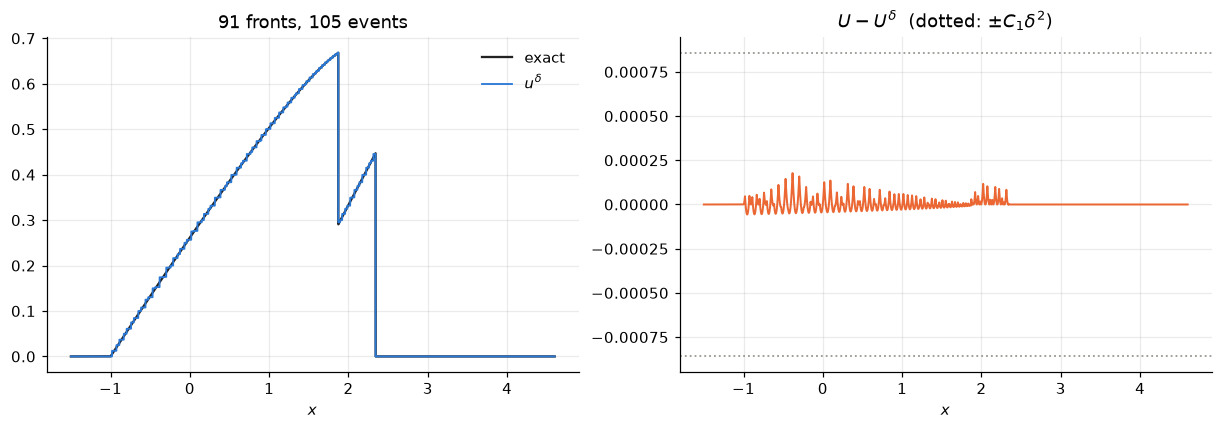

In [10]:
import ipywidgets as widgets
controls = dict(
    k=widgets.IntSlider(value=2, min=0, max=6, description="δ = 0.1/2^k"),
    T=widgets.FloatSlider(value=3.0, min=0.5, max=6.0, step=0.5, description="T"),
    projection=widgets.Dropdown(options=["mass-preserving", "nearest node"],
                                value="mass-preserving", description="projection"))
def show(k, T, projection):
    d = 0.1 / 2**k
    tr = (mass_projection(burgers, U0, [-1.0, 1.0, 1.5], d, 2 * A, 0.0, 1.0)
          if projection == "mass-preserving"
          else nearest_projection(burgers, u0, -1.0, 1.5, d, 0.0, 1.0)).run(T)
    x = np.sort(np.concatenate([np.linspace(-1.5, 1.6 + T, 20_001), front_positions(tr)]))
    u_ex, U_ex, _ = burgers_exact(x, T)
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
    a.plot(x, u_ex, color=C_EXACT, lw=1.5, label="exact")
    a.step(x, tr.sample(x), where="post", color=C_POLY, lw=1.2, label=r"$u^\delta$")
    a.set(xlabel="$x$", title=f"{len(tr.fronts)} fronts, {tr.event_count} events")
    a.legend(frameon=False)
    b.plot(x, U_ex - primitive(tr, x), color=C_ENV, lw=1.3)
    for s in (1, -1):
        b.axhline(s * (1 + T / 8) * d**2, color=C_FLUX, ls=":", lw=1.2)
    b.set(xlabel="$x$", title=r"$U - U^\delta$  (dotted: $\pm C_1\delta^2$)")
    plt.show()
display(widgets.HBox(list(controls.values()), layout=widgets.Layout(flex_flow="row wrap")),
        widgets.interactive_output(show, controls))

## References

* C. M. Dafermos, Polygonal approximations of solutions of the initial value problem for a
  conservation law, *J. Math. Anal. Appl.* **38**(1) (1972) 33–41.
* S. N. Kružkov, First order quasilinear equations in several independent variables,
  *Math. USSR-Sb.* **10** (1970) 217–243.
* N. N. Kuznetsov, Accuracy of some approximate methods for computing the weak solutions of a
  first-order quasi-linear equation, *USSR Comput. Math. Math. Phys.* **16** (1976) 105–119.
* B. J. Lucier, A moving mesh numerical method for hyperbolic conservation laws,
  *Math. Comp.* **46** (1986) 59–69.
* F. Şabac, The optimal convergence rate of monotone finite difference methods for hyperbolic
  conservation laws, *SIAM J. Numer. Anal.* **34** (1997) 2306–2318.
* K. H. Karlsen, N. H. Risebro, A note on front tracking and the equivalence between viscosity
  solutions of Hamilton–Jacobi equations and entropy solutions of scalar conservation laws,
  *Nonlinear Anal.* **50** (2002) 455–469.
* S. Solem, Convergence rates of the front tracking method for conservation laws in the
  Wasserstein distances, *SIAM J. Numer. Anal.* **56** (2018) 3648–3666.
* S. S. Ghoshal, J. D. Towers, A convergence rate result for front tracking approximations of
  conservation laws with discontinuous flux, arXiv:2509.22952 (2025).
* J. R. Shewchuk, Adaptive precision floating-point arithmetic and fast robust geometric
  predicates, *Discrete Comput. Geom.* **18** (1997) 305–363. (Background on orientation tests.)
* H. Holden, N. H. Risebro, *Front Tracking for Hyperbolic Conservation Laws*, 2nd ed.,
  Springer (2015).

---
**Next:** *06 · Stability*: $L^1$ contraction, total variation, and how many fronts there can be.